# **((Exploratory Data Analysis))**|

## Objectives

* "Here, we will view our dataset and plot the class distribution, data distribution, the average images, average variability, and both image montages for malignant and benign labels

## Inputs

* inputs/skin_cancer_dataset/melanoma_cancer_dataset/test
* inputs/skin_cancer_dataset/melanoma_cancer_dataset/train
* inputs/skin_cancer_dataset/melanoma_cancer_dataset/validation

## Outputs

* outputs/v1/

## Additional Comments

No additional comments

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/workspaces/skin-lesion-detector/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/workspaces/skin-lesion-detector'

---

# Data Directories

## Input Directories

Set train, validation, and test set paths so machine knows where the data is

In [4]:
my_data_dir = 'inputs/skin_cancer_dataset/melanoma_cancer_dataset'
train_path = my_data_dir + '/train'
validation_path = my_data_dir + '/validation'
test_path = my_data_dir + '/test'

## Output Directories

Set output directories so the machine knows where to place the outputs

In [5]:
version = 'v1'
file_path = f'outputs/{version}'

if 'outputs' in os.listdir(current_dir) and version in os.listdir(current_dir + '/outputs'):
    print("outputs directory already exists")
    pass
else:
    os.makedirs(file_path)
    print("outputs directory created")

outputs directory created


# Set Label Names

Setting label names to know difference

In [6]:
labels = os.listdir(train_path)
print(f"Labels: {labels}")

Labels: ['malignant', 'benign']


# Plotting Class Distribution

We will see how our classes(or labels) are distributed.

train set has 3573 images for label malignant
train set has 3849 images for label benign
validation set has 510 images for label malignant
validation set has 550 images for label benign
test set has 1022 images for label malignant
test set has 1101 images for label benign




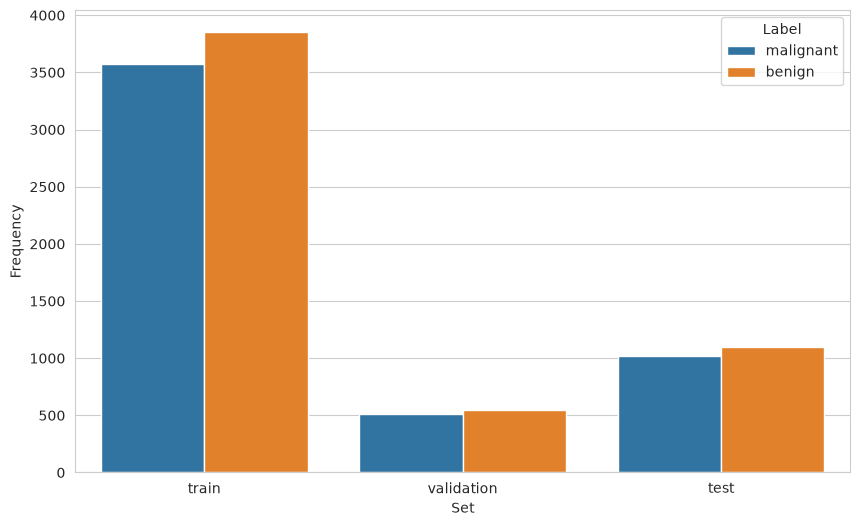

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

data = {
    'Set': [],
    'Label': [],
    'Frequency': []
}

# Number or rows
folders = ['train', 'validation', 'test']

for folder in folders:
    for label in labels:
        row = {
            'Set': folder,
            'Label': label,
            'Frequency': int(len(os.listdir(my_data_dir + '/' + folder + '/' + label)))
        }
        for key, value in row.items():
            data[key].append(value)
        print(
            f"{folder} set has {row['Frequency']} images for label {label}"
        )

#convert to a dataframe
df_freq = pd.DataFrame(data)

print("\n")
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(x='Set', y='Frequency', hue='Label', data=df_freq)
plt.savefig(f'{file_path}/labels_distribution.png', bbox_inches = 'tight', dpi=150)

plt.show()

As we can see, there is less than a 10% difference in the number of images for each label(or class). Thus, proving that the dataset is balanced between classes